# Github repositories
Participants in the group worked on the weekly exercises individually prior to forming groups. Each member has looked at the exercises indivually prior to the assignment. The implementation in this notebook was created by comparing and discussing individual answers of group members.

Mikel's repository: https://github.com/Mikel-Yu/comsocsci2026_private

Poul's repository: https://github.com/poulguoskov/cososc

# Part 1: Mixing Patterns and Assortativity

> __Exercise 1: Mixing Patterns and Assortativity__  
>
> __Part 1: Assortativity Coefficient__ 
> 1. *Calculate the Assortativity Coefficient* for the network based on the country of each node. Implement the calculation using the formula provided during the lecture, also available in [this paper](https://arxiv.org/pdf/cond-mat/0209450.pdf) (equation 2, here for directed networks). **Do not use the NetworkX implementation.**

In [1]:
"""
Exercise 1 - Part 1: Assortativity Coefficient
Calculates the categorical assortativity coefficient based on node country attribute.
Formula: Newman (2003), Eq. 2 for directed networks (categorical attributes).

r = (sum_i e_ii - sum_i a_i * b_i) / (1 - sum_i a_i * b_i)

where:
  e_ij = fraction of edges going from nodes of type i to nodes of type j
  a_i  = sum_j e_ij  (row sums = fraction of edges leaving type i)
  b_i  = sum_j e_ji  (col sums = fraction of edges arriving at type i)
"""

import json
import numpy as np
from collections import defaultdict

In [2]:
# ── 1. Load network ──────────────────────────────────────────────────────────
with open("css_network.json", "r") as f:
    data = json.load(f)

# Support both node-link format (networkx default) and adjacency formats
nodes_raw = data.get("nodes", [])
edges_raw = data.get("links", data.get("edges", []))

# Build id → country lookup
node_attr = {}
for n in nodes_raw:
    nid = n.get("id")
    country = n.get("country_code", None)
    node_attr[nid] = country

print(f"Nodes loaded : {len(node_attr)}")
print(f"Edges loaded : {len(edges_raw)}")

Nodes loaded : 21693
Edges loaded : 87076


In [3]:
# ── 2. Extract GCC (Giant Connected Component) ───────────────────────────────
from collections import deque

# Build adjacency list (undirected for component detection)
adj = defaultdict(set)
for e in edges_raw:
    u = e.get("source", e.get("from"))
    v = e.get("target", e.get("to"))
    adj[u].add(v)
    adj[v].add(u)

def bfs_component(start, visited):
    comp = set()
    q = deque([start])
    while q:
        node = q.popleft()
        if node in visited:
            continue
        visited.add(node)
        comp.add(node)
        for nb in adj[node]:
            if nb not in visited:
                q.append(nb)
    return comp

visited = set()
components = []
for node in node_attr:
    if node not in visited:
        comp = bfs_component(node, visited)
        components.append(comp)

gcc = max(components, key=len)
print(f"\nGCC size     : {len(gcc)} nodes")

# Filter edges to GCC only
gcc_edges = [
    e for e in edges_raw
    if e.get("source", e.get("from")) in gcc
    and e.get("target", e.get("to")) in gcc
]
print(f"GCC edges    : {len(gcc_edges)}")


GCC size     : 21002 nodes
GCC edges    : 85426


In [4]:
# ── 3. Build e_ij matrix (mixing matrix) ─────────────────────────────────────
# Collect all unique countries in GCC
countries = sorted(set(
    node_attr[n] for n in gcc
    if node_attr.get(n) is not None and isinstance(node_attr.get(n), str)
))
cat_index = {c: i for i, c in enumerate(countries)}
C = len(countries)
print(f"Unique countries in GCC: {C}")

# Count directed edge pairs (type_source → type_target)
edge_counts = defaultdict(int)
valid_edges = 0

for e in gcc_edges:
    u = e.get("source", e.get("from"))
    v = e.get("target", e.get("to"))
    cu = node_attr.get(u)
    cv = node_attr.get(v)
    if not isinstance(cu, str) or not isinstance(cv, str): 
        continue
    edge_counts[(cu, cv)] += 1
    valid_edges += 1

print(f"Edges with country info: {valid_edges}")

# Normalise to get e_ij (fraction of all edges)
e = np.zeros((C, C))
for (ci, cj), count in edge_counts.items():
    e[cat_index[ci], cat_index[cj]] = count / valid_edges

Unique countries in GCC: 119
Edges with country info: 60840


In [5]:
# ── 4. Compute assortativity coefficient ──────────────────────────────────────
# a_i = row sums (fraction of edges leaving category i)
a = e.sum(axis=1)
# b_i = col sums (fraction of edges entering category i)
b = e.sum(axis=0)

trace_e   = np.trace(e)           # sum_i e_ii
sum_ab    = np.dot(a, b)          # sum_i a_i * b_i

r = (trace_e - sum_ab) / (1 - sum_ab)

In [6]:
# ── 5. Report ─────────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("  Assortativity Coefficient (by country, directed)")
print("="*55)
print(f"  Tr(e)         = sum_i e_ii   = {trace_e:.6f}")
print(f"  sum_i a_i*b_i              = {sum_ab:.6f}")
print(f"  r = (Tr(e) - sum ab) / (1 - sum ab)")
print(f"  r                          = {r:.6f}")
print("="*55)
print()
if r > 0:
    print("  Interpretation: ASSORTATIVE mixing. Nodes tend to")
    print("  connect with others from the same country.")
elif r < 0:
    print("  Interpretation: DISASSORTATIVE mixing. Nodes tend to")
    print("  connect with others from different countries).")
else:
    print("  Interpretation: NEUTRAL mixing. No preference.")


  Assortativity Coefficient (by country, directed)
  Tr(e)         = sum_i e_ii   = 0.493491
  sum_i a_i*b_i              = 0.156403
  r = (Tr(e) - sum ab) / (1 - sum ab)
  r                          = 0.399585

  Interpretation: ASSORTATIVE mixing. Nodes tend to
  connect with others from the same country.


> __Part 2: Configuration model__
> In the following, we are going to assess the significance of the assortativity by comparing the network's assortativity coefficient against that of random networks generated through the configuration model.  
>
> 2. *Implement the configuration model* using the _double edge swap_ algorithm to generate random networks. Ensure each node retains its original degree but with altered connections. Create a function that does that by following these steps:
>
>   - **a.** Create an exact copy of your original network.
>   - **b.** Select two edges, $e_{1} = (u,v)$ and $e_{2} = (x,y)$, ensuring *u != y* and *v != x*.
>   - **c.** Flip the direction of $e_{1}$ to $e_{1} = (v,u)$ 50% of the time. This ensure that your final results is not biased, in case your edges were sorted (they usually are). 
>   - **d.** Ensure that new edges $e_{1}' = (e_{1}[0],e_{2}[1])$ and $e_{2}' = (e_{2}[0],e_{1}[1])$ do not already exist in the network.
>   - **e.** Remove edges $e_{1}$ and $e_{2}$ and add edges $e_{1}'$ and $e_{2}'$.
>   - **f.** Repeat steps **b** to **e** until you have performed $E\cdot10$ swaps, where E is the total number of edges.
>
> 3. *Double check that your algorithm works well*, by showing that the degree of nodes in the original network and the new 'randomized' version of the network are the same.


In [7]:
"""
Exercise 1 - Part 2: Configuration Model via Double Edge Swap
Generates randomized networks preserving the degree sequence,
then verifies degree preservation (step 3).
"""

import random
import copy

In [8]:
def double_edge_swap(edges, n_swaps=None):
    edge_list = list(edges)
    edge_set  = set(edge_list)

    E = len(edge_list)
    if n_swaps is None:
        n_swaps = 10 * E

    successful = 0
    attempts   = 0
    max_attempts = 100 * n_swaps

    while successful < n_swaps and attempts < max_attempts:
        attempts += 1

        # b. Pick two distinct edges
        idx1, idx2 = random.sample(range(len(edge_list)), 2)
        u, v = edge_list[idx1]
        x, y = edge_list[idx2]

        # c. Flip: swap roles of e1 and e2 50% of the time (avoids sorted-edge bias)
        if random.random() < 0.5:
            u, v, x, y = x, y, u, v

        # b. Ensure no degenerate swap
        if u == y or v == x:
            continue

        # d. Candidate new edges (swap targets — preserves out-degree of u,x and in-degree of v,y)
        e1_new = (u, y)
        e2_new = (x, v)

        if e1_new in edge_set or e2_new in edge_set:
            continue
        if e1_new[0] == e1_new[1] or e2_new[0] == e2_new[1]:
            continue

        # e. Remove old, add new
        orig_e1 = edge_list[idx1]
        orig_e2 = edge_list[idx2]

        edge_set.discard(orig_e1)
        edge_set.discard(orig_e2)
        edge_set.add(e1_new)
        edge_set.add(e2_new)

        edge_list[idx1] = e1_new
        edge_list[idx2] = e2_new

        successful += 1

    print(f"  Swaps requested : {n_swaps}")
    print(f"  Successful swaps: {successful}")
    return edge_list

In [9]:
# ── Prepare edge list as tuples from gcc_edges ────────────────────────────────
original_edges = [
    (e.get("source", e.get("from")), e.get("target", e.get("to")))
    for e in gcc_edges
]

# ── Run the configuration model ───────────────────────────────────────────────
print("Running double edge swap configuration model...")
randomized_edges = double_edge_swap(original_edges)

Running double edge swap configuration model...
  Swaps requested : 854260
  Successful swaps: 854260


In [10]:
# ── Step 3: Verify degree sequence is preserved ───────────────────────────────
def degree_sequence(edges):
    """Returns dicts of in-degree and out-degree per node."""
    out_deg = defaultdict(int)
    in_deg  = defaultdict(int)
    for u, v in edges:
        out_deg[u] += 1
        in_deg[v]  += 1
    return out_deg, in_deg

orig_out, orig_in   = degree_sequence(original_edges)
rand_out, rand_in   = degree_sequence(randomized_edges)

In [11]:
# Collect all nodes
all_nodes = set(orig_out) | set(orig_in) | set(rand_out) | set(rand_in)

out_match = all(orig_out[n] == rand_out[n] for n in all_nodes)
in_match  = all(orig_in[n]  == rand_in[n]  for n in all_nodes)

print("\n── Degree Preservation Check ──────────────────────────────────")
print(f"  Out-degree preserved for all nodes: {out_match}")
print(f"  In-degree  preserved for all nodes: {in_match}")

if out_match and in_match:
    print("Configuration model preserves the full degree sequence.")
else:
    # Show which nodes differ (first 5)
    bad_out = [n for n in all_nodes if orig_out[n] != rand_out[n]][:5]
    bad_in  = [n for n in all_nodes if orig_in[n]  != rand_in[n]][:5]
    print(f"  Nodes with mismatched out-degree (first 5): {bad_out}")
    print(f"  Nodes with mismatched in-degree  (first 5): {bad_in}")

# ── Quick summary stats ───────────────────────────────────────────────────────
orig_out_vals = np.array([orig_out[n] for n in all_nodes])
rand_out_vals = np.array([rand_out[n] for n in all_nodes])

print(f"\n  Original  mean out-degree: {orig_out_vals.mean():.4f}")
print(f"  Randomized mean out-degree: {rand_out_vals.mean():.4f}")
print(f"  Max out-degree difference : {np.abs(orig_out_vals - rand_out_vals).max()}")



── Degree Preservation Check ──────────────────────────────────
  Out-degree preserved for all nodes: True
  In-degree  preserved for all nodes: True
Configuration model preserves the full degree sequence.

  Original  mean out-degree: 4.0675
  Randomized mean out-degree: 4.0675
  Max out-degree difference : 0


> __Part 3: Analyzing Assortativity in Random Networks__  
>
> 4. *Generate and analyze at least 100 random networks* using the configuration model. For each, calculate the assortativity with respect to the country and plot the distribution of these values. Compare the results with the assortativity of your original network to determine if connections within the same country are significantly higher than chance.

In [12]:
"""
Exercise 1 - Part 3: Assortativity in Random Networks
Generates 100 configuration-model networks, computes assortativity for each,
and compares the distribution to the original network's assortativity.

Assumes from Part 1: original_edges, node_attr, gcc
Assumes from Part 2: double_edge_swap(), compute_assortativity()
"""

import matplotlib.pyplot as plt

In [13]:
# ── Helper: compute categorical assortativity from an edge list ───────────────
def compute_assortativity(edges, node_attr):
    """
    Newman (2003) Eq. 2 — categorical assortativity for directed networks.
    Skips edges where either endpoint has a non-string (NaN/None) country_code.
    """
    edge_counts = defaultdict(int)
    valid = 0
    for u, v in edges:
        cu = node_attr.get(u)
        cv = node_attr.get(v)
        if not isinstance(cu, str) or not isinstance(cv, str):
            continue
        edge_counts[(cu, cv)] += 1
        valid += 1

    if valid == 0:
        return float("nan")

    # Build e_ij matrix
    categories = sorted(set(c for pair in edge_counts for c in pair))
    cat_index  = {c: i for i, c in enumerate(categories)}
    C = len(categories)

    e = np.zeros((C, C))
    for (ci, cj), count in edge_counts.items():
        e[cat_index[ci], cat_index[cj]] = count / valid

    a = e.sum(axis=1)   # row sums
    b = e.sum(axis=0)   # col sums

    trace_e = np.trace(e)
    sum_ab  = np.dot(a, b)

    if sum_ab == 1.0:
        return float("nan")

    return (trace_e - sum_ab) / (1 - sum_ab)

In [14]:
# ── Original assortativity ────────────────────────────────────────────────────
r_original = compute_assortativity(original_edges, node_attr)
print(f"Original network assortativity: r = {r_original:.4f}")

Original network assortativity: r = 0.3996


In [15]:
# ── Generate 100 random networks and compute assortativity ───────────────────
N_RANDOM = 100
random_r  = []

print(f"\nGenerating {N_RANDOM} random networks via configuration model...")
for i in range(N_RANDOM):
    rand_edges = double_edge_swap(original_edges)
    r = compute_assortativity(rand_edges, node_attr)
    random_r.append(r)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{N_RANDOM} done — r = {r:.4f}")

random_r = np.array(random_r)
print(f"\nRandom networks — mean r: {random_r.mean():.4f}, std: {random_r.std():.4f}")


Generating 100 random networks via configuration model...
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  10/100 done — r = -0.0001
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 85

In [16]:
# ── Z-score ───────────────────────────────────────────────────────────────────
z = (r_original - random_r.mean()) / random_r.std()
p_approx = np.mean(random_r >= r_original)   # empirical one-tailed p-value
print(f"Z-score: {z:.2f}")
print(f"Empirical p-value (fraction of random r >= original r): {p_approx:.4f}")

Z-score: 265.74
Empirical p-value (fraction of random r >= original r): 0.0000


P value extremely small.

In [17]:
n = len(random_r)
# p=0/100 means we can only bound it; report as p < 1/N
if p_approx == 0:
    print(f"p < {1/n:.3f} (upper bound, no random network reached r_original)")
else:
    print(f"p = {p_approx:.4f}")

p < 0.010 (upper bound, no random network reached r_original)


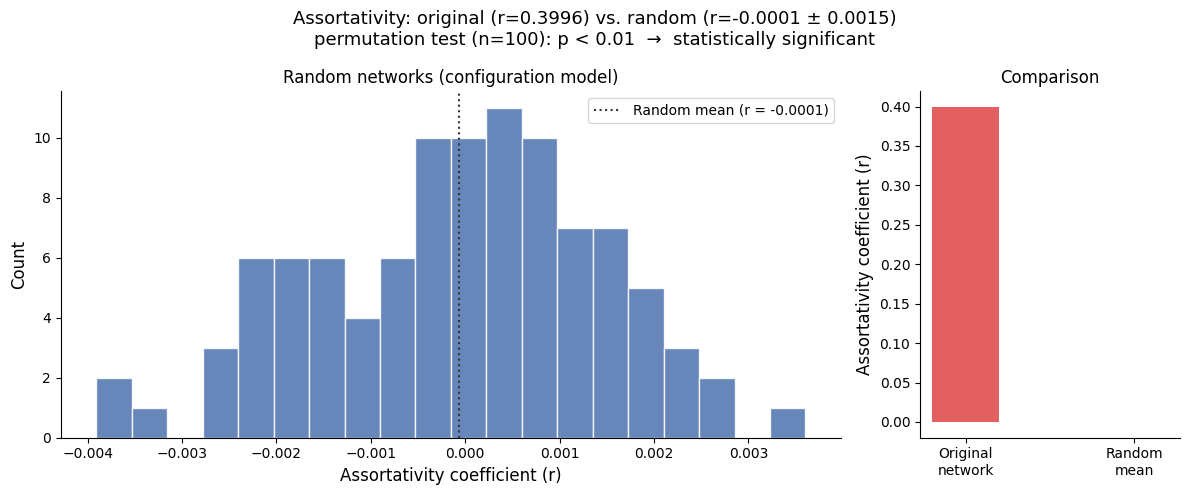

In [18]:
# Format p-value string
n = len(random_r)
p_str = f"< {1/n:.2f}" if p_approx == 0 else f"= {p_approx:.4f}"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5),
                                gridspec_kw={"width_ratios": [3, 1]})

# Left: zoom in on random distribution
ax1.hist(random_r, bins=20, color="#4C72B0", edgecolor="white", alpha=0.85)
ax1.axvline(random_r.mean(), color="#333333", linewidth=1.5,
            linestyle=":", label=f"Random mean (r = {random_r.mean():.4f})")
ax1.set_xlabel("Assortativity coefficient (r)", fontsize=12)
ax1.set_ylabel("Count", fontsize=12)
ax1.set_title("Random networks (configuration model)", fontsize=12)
ax1.legend(fontsize=10)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# Right: original network as a single bar for visual comparison
ax2.bar(["Original\nnetwork"], [r_original], color="#DD4444", alpha=0.85, width=0.4)
ax2.bar(["Random\nmean"], [random_r.mean()], color="#4C72B0", alpha=0.85, width=0.4)
ax2.set_ylabel("Assortativity coefficient (r)", fontsize=12)
ax2.set_title("Comparison", fontsize=12)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

fig.suptitle(f"Assortativity: original (r={r_original:.4f}) vs. "
             f"random (r={random_r.mean():.4f} ± {random_r.std():.4f})\n"
             f"permutation test (n={n}): p {p_str}  →  statistically significant",
             fontsize=13)
plt.tight_layout()
plt.savefig("assortativity_distribution.png", dpi=150)
plt.show()

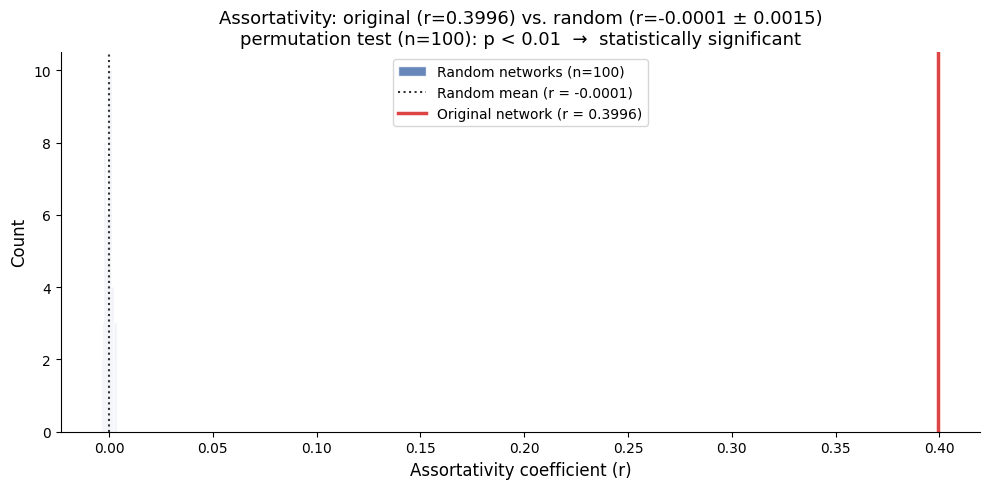

In [42]:
# Single-axis version: random distribution + original network on the same axis
n = len(random_r)
p_str = f"< {1/n:.2f}" if p_approx == 0 else f"= {p_approx:.4f}"

fig, ax = plt.subplots(figsize=(10, 5))

# Histogram of random networks
ax.hist(random_r, bins=20, color="#4C72B0", edgecolor="white", alpha=0.85,
        label=f"Random networks (n={n})")

# Random mean as a dotted line
ax.axvline(random_r.mean(), color="#333333", linewidth=1.5, linestyle=":",
           label=f"Random mean (r = {random_r.mean():.4f})")

# Original network as a solid red line — far to the right of the random cloud
ax.axvline(r_original, color="#DD4444", linewidth=2.5,
           label=f"Original network (r = {r_original:.4f})")

# Because r_original is ~0.4 and the random distribution sits near 0,
# the x-axis must span both. Add a little padding on each side.
xmin = min(random_r.min(), r_original) - 0.02
xmax = max(random_r.max(), r_original) + 0.02
ax.set_xlim(xmin, xmax)

ax.set_xlabel("Assortativity coefficient (r)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title(
    f"Assortativity: original (r={r_original:.4f}) vs. "
    f"random (r={random_r.mean():.4f} ± {random_r.std():.4f})\n"
    f"permutation test (n={n}): p {p_str}  →  statistically significant",
    fontsize=13,
)
ax.legend(fontsize=10, loc="upper center")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("assortativity_distribution_single_axis.png", dpi=150)
plt.show()

The assortativity coefficients of the random networks are extremely small values centered around 0, meaning that assortivity with resepct to country is weak. In comparison, the original network has an assortativity coefficient of $r=0.3996$ which is statistically different the random networks. This results indicates that connections within the same country are indeed higher than chance.

> __Part 4: Assortativity by Degree__
>
> 5. *Calculate degree assortativity* for your network using the formula discussed in the lecture.
> 6. *Compare your network's degree assortativity* against that of 100 random networks generated via the configuration model. Analyze whether your network shows a tendency for high-degree scientists to connect with other high-degree scientists and vice versa. 

Use Newman (2003), Equation 4 for directed networks.

For each edge $( i )$ from $( u \rightarrow v )$:

- $( j_i )$: out-degree of source node $( u )$  
- $( k_i )$: in-degree of target node $( v )$

The assortativity coefficient $( r )$ is defined as:

$$
r =
\frac{
M^{-1} \sum j_i k_i \;-\; \left( M^{-1} \sum \frac{j_i + k_i}{2} \right)^2
}{
M^{-1} \sum \frac{j_i^2 + k_i^2}{2} \;-\; \left( M^{-1} \sum \frac{j_i + k_i}{2} \right)^2
}
$$

In [19]:
# ── Helper: compute degree assortativity from an edge list ────────────────────
def compute_degree_assortativity(edges):
    """
    Newman (2003) Eq. 4 — degree assortativity for directed networks.
    j_i = out-degree of source, k_i = in-degree of target, for each edge i.
    """
    edges = list(edges)
    M = len(edges)
    if M == 0:
        return float("nan")

    # Compute out-degree (source) and in-degree (target) for every node
    out_deg = defaultdict(int)
    in_deg  = defaultdict(int)
    for u, v in edges:
        out_deg[u] += 1
        in_deg[v]  += 1

    # For each edge collect j_i, k_i
    j = np.array([out_deg[u] for u, v in edges], dtype=float)
    k = np.array([in_deg[v]  for u, v in edges], dtype=float)

    M_inv = 1.0 / M

    numerator   = M_inv * np.sum(j * k) - (M_inv * np.sum((j + k) / 2)) ** 2
    denominator = M_inv * np.sum((j**2 + k**2) / 2) - (M_inv * np.sum((j + k) / 2)) ** 2

    if denominator == 0:
        return float("nan")
    return numerator / denominator


In [20]:
# ── 5. Degree assortativity of original network ───────────────────────────────
r_degree_original = compute_degree_assortativity(original_edges)
print(f"Original network degree assortativity: r = {r_degree_original:.4f}")


Original network degree assortativity: r = -0.0926


In [21]:
# ── 6. Compare against 100 random networks ────────────────────────────────────
N_RANDOM = 100
random_r_degree = []

print(f"\nGenerating {N_RANDOM} random networks...")
for i in range(N_RANDOM):
    rand_edges = double_edge_swap(original_edges)
    r = compute_degree_assortativity(rand_edges)
    random_r_degree.append(r)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{N_RANDOM} done — r = {r:.4f}")

random_r_degree = np.array(random_r_degree)

# p-value
p_degree = np.mean(random_r_degree <= r_degree_original)   # two-sided: check which tail
# For disassortative (negative r), check lower tail; for assortative, upper tail
# Use two-tailed framing:
p_upper = np.mean(random_r_degree >= r_degree_original)
p_lower = np.mean(random_r_degree <= r_degree_original)
p_degree = 2 * min(p_upper, p_lower)   # two-tailed

n = len(random_r_degree)
p_str = f"< {2/n:.3f}" if p_degree == 0 else f"= {p_degree:.4f}"

print(f"\nRandom networks — mean r: {random_r_degree.mean():.4f}, "
      f"std: {random_r_degree.std():.4f}")
print(f"Two-tailed permutation p {p_str}")


Generating 100 random networks...
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  10/100 done — r = -0.0814
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested :

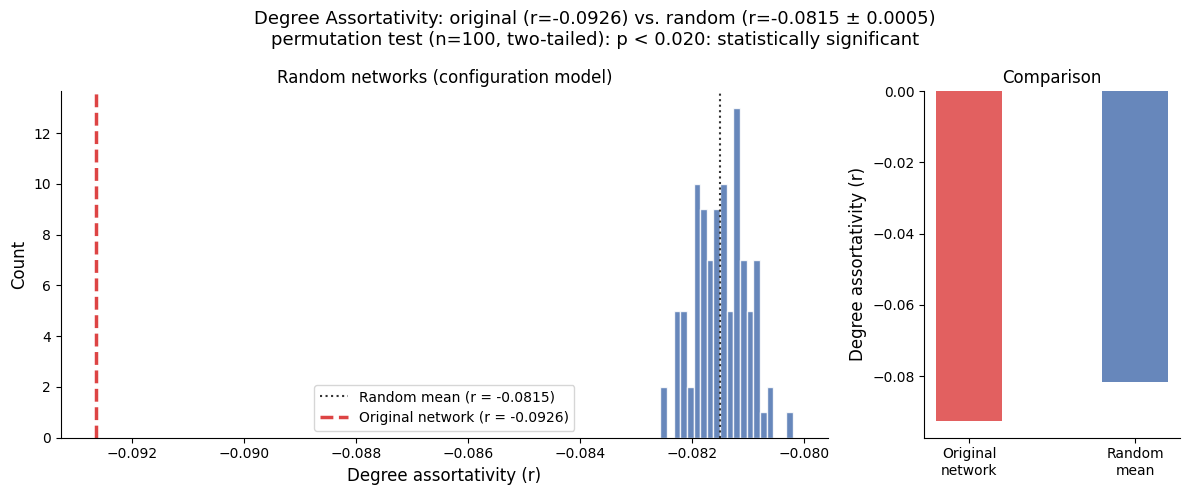

In [22]:
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5),
                                gridspec_kw={"width_ratios": [3, 1]})

ax1.hist(random_r_degree, bins=20, color="#4C72B0", edgecolor="white", alpha=0.85)
ax1.axvline(random_r_degree.mean(), color="#333333", linewidth=1.5,
            linestyle=":", label=f"Random mean (r = {random_r_degree.mean():.4f})")
ax1.axvline(r_degree_original, color="#DD4444", linewidth=2.5,
            linestyle="--", label=f"Original network (r = {r_degree_original:.4f})")
ax1.set_xlabel("Degree assortativity (r)", fontsize=12)
ax1.set_ylabel("Count", fontsize=12)
ax1.set_title("Random networks (configuration model)", fontsize=12)
ax1.legend(fontsize=10)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

ax2.bar(["Original\nnetwork"], [r_degree_original], color="#DD4444", alpha=0.85, width=0.4)
ax2.bar(["Random\nmean"], [random_r_degree.mean()], color="#4C72B0", alpha=0.85, width=0.4)
ax2.set_ylabel("Degree assortativity (r)", fontsize=12)
ax2.set_title("Comparison", fontsize=12)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

fig.suptitle(f"Degree Assortativity: original (r={r_degree_original:.4f}) vs. "
             f"random (r={random_r_degree.mean():.4f} ± {random_r_degree.std():.4f})\n"
             f"permutation test (n={n}, two-tailed): p {p_str}: statistically significant",
             fontsize=13)
plt.tight_layout()
plt.savefig("degree_assortativity_distribution.png", dpi=150)
plt.show()

Both degreee assortativity values are negative, indicating disassorsative networks. Additionally, given that the degree assortativity of the original network is not only higher than any of the 100 randomly generated networks but also different  with statistical significance, it indicates it that high-degree scientists do not tend to connect with other high-degree scientists within the network. Instead, they tend to connect to lower-degree scientists. This is expected within the research community where few prolific authors collaborate with a broad range of lesser connected authors. 

> __Part 5: Reflection questions__    
> 7. *Assortativity by degree.* Were the results of the degree assortativity in line with your expectations? Why or why not?    
> 8. *Edge flipping.* In the process of implementing the configuration model, you were instructed to flip the edges (e.g., changing $e_1$ from (u,v) to (v,u)) 50% of the time. Why do you think this step is included?    
> 9. *Distribution of assortativity in random networks.* Describe the distribution of degree assortativity values you observed for the random networks. Was the distribution pattern expected? Discuss how the nature of random network generation (specifically, the configuration model and edge flipping) might influence this distribution and whether it aligns with theoretical expectations.    

Q7 — CSS networks are typically disassortative by degree (hubs connect to periphery), so a negative r is expected. Highly cited scientists tend to connect to many smaller nodes rather than exclusively to each other. An example of this is well-established professors collaborating with students, junior researchers, or low degree authors.

Q8 — The flip prevents bias from edge ordering; without it the swap systematically favors certain node pairs over others

Q9 — Random networks should give r ≈ 0 in a narrow bell-shaped distribution; any deviation in the original is genuine network structure, not a degree-sequence artifact.

# Part 2: TF-IDF

> __Exercise 1: TF-IDF and the Computational Social Science communities.__ The goal for this exercise is to find the words charachterizing each of the communities of Computational Social Scientists.
> What you need for this exercise: 
>.   
>    * The assignment of each author to their network community, and the degree of each author (Week 6, Exercise 4). This can be stored in a dataframe or in two dictionaries, as you prefer.  
>    * the tokenized _abstract_ dataframe (Week 7, Exercise 2)
>
> 1. First, check out [the wikipedia page for TF-IDF](https://en.wikipedia.org/wiki/Tf%E2%80%93idf). Explain in your own words the point of TF-IDF. 
>   * What does TF stand for? 
>   * What does IDF stand for?

The terms TF and IDF stand for term frequency and inverse document frequency, respectively. Both are measures to quantify the relevance of a word to a document in a corpus of documents. The former measures how often a specific term $t$ appears in a given document $d$ divided by the total amount of terms $t'$ in $d$, hence 'frequency', ie
\begin{equation}
    tf(t,d) = \frac{f_{t,d}}{\sum_{t'\in d}f_{t',d}}
\end{equation}

This term is useful for capturing local importance within an individual document.
The latter, inverse document frequency, measures how rare a term is across the entire collection of documents. It is originally given by
\begin{equation}
    idf(t,D) = log \frac{N}{n_t}
\end{equation}
Where $D$ denotes the set of all documents in a given corpus, $N=|D|$ denotes the total number of documents in a corpus, and $n_t=|\{d\in D:t \in d\}|$ denotes the number of documents where the term $t$ appears, ie $tf(t,d) \neq 0$. However, if the term is not in the corpus, $n_t=0$ and lead to a division by $0$. Therefore, it is common to append 1 to both the numerator and denominator instead:
\begin{equation}
    idf(t,D) = log \frac{N+1}{n_t+1}
\end{equation}
The IDF measures how common a term is across the entire corpus. A rare term will yield a high IDF value and vice versa. 

> 2. Now, we want to find out which words are important for each *community*, so we're going to create several ***large documents, one for each community***. Each document includes all the tokens of abstracts written by members of a given community. 
>   * Consider a community _c_
>   * Find all the abstracts of papers written by a member of community _c_.
>   * Create a long array that stores all the abstract tokens 
>   * Repeat for all the communities. 
> __Note:__ Here, to ensure your code is efficient, you shall exploit ``pandas`` builtin functions, such as [``groupby.apply``](https://pandas.pydata.org/docs/reference/api/pandas.api.typing.DataFrameGroupBy.apply.html) or [``explode``](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.explode.html).

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import json

# load communities
community_df = pd.read_json("week6_communities.json")
comm_dict = dict(zip(community_df["author_id"], community_df["community"]))

# load tokenized abstracts
abstracts = pd.read_json("week7_abstracts_tokenized.json")

# load papers to link abstracts -> authors
papers = pd.read_json("week3_css_papers.json")

# load authors for display names
authors = pd.read_json("week3_css_authors.json")

print(f"Communities: {len(comm_dict)} authors")
print(f"Abstracts: {len(abstracts)}")
print(f"Papers: {len(papers)}")
print(papers.columns.tolist())

Communities: 17802 authors
Abstracts: 47599
Papers: 47599
['id', 'publication_year', 'cited_by_count', 'author_ids']


In [24]:
# assign each paper to communities via its authors
paper_communities = []
for _, row in papers.iterrows():
    comms = set()
    for aid in row["author_ids"]:
        if aid in comm_dict:
            comms.add(comm_dict[aid])
    paper_communities.append(comms)

papers["communities"] = paper_communities

# merge abstracts with papers
abstracts["communities"] = papers["communities"]

# for each community, collect all tokens
# explode so each row is one (abstract, community) pair
abs_exploded = abstracts[["tokens", "communities"]].explode("communities")
abs_exploded = abs_exploded.dropna(subset=["communities"])

print(f"Abstract-community pairs: {len(abs_exploded)}")

# get top 5 communities by author count
comm_sizes = Counter(comm_dict.values())
top5 = [c for c, _ in comm_sizes.most_common(5)]
print(f"Top 5 communities: {top5}")

Abstract-community pairs: 57477
Top 5 communities: [19, 21, 22, 35, 4]


In [25]:
# build a dict: community -> list of all tokens
comm_tokens = {}
for _, row in abs_exploded.iterrows():
    c = int(row["communities"])
    if c not in comm_tokens:
        comm_tokens[c] = []
    comm_tokens[c].extend(row["tokens"])

# check sizes for top 5
for c in top5:
    print(f"Community {c}: {len(comm_tokens.get(c, []))} tokens")

Community 19: 264583 tokens
Community 21: 216578 tokens
Community 22: 274049 tokens
Community 35: 167929 tokens
Community 4: 121624 tokens


> 3. Now, we're ready to calculate the TF for each word. Use the method of your choice to find the top 5 terms within the __top 5 communities__ (by number of authors). 
>   * Describe similarities and differences between the communities.
>   * Why aren't the TFs not necessarily a good description of the communities?
>   * Next, we calculate IDF for every word. 
>   * What base logarithm did you use? Is that important?

In [26]:
# TF = count of word / total words in community document
comm_tf = {}
for c in top5:
    token_counts = Counter(comm_tokens[c])
    total = len(comm_tokens[c])
    comm_tf[c] = {word: count / total for word, count in token_counts.items()}

# top 5 TF words per community
print("Top 5 words by TF per community:\n")
for c in top5:
    top_words = sorted(comm_tf[c].items(), key=lambda x: x[1], reverse=True)[:5]
    print(f"Community {c}: {[(w, f'{tf:.4f}') for w, tf in top_words]}")

Top 5 words by TF per community:

Community 19: [('users', '0.0045'), ('people', '0.0038'), ('work', '0.0037'), ('use', '0.0035'), ('data', '0.0034')]
Community 21: [('model', '0.0061'), ('models', '0.0058'), ('task', '0.0054'), ('data', '0.0040'), ('using', '0.0037')]
Community 22: [('model', '0.0058'), ('image', '0.0050'), ('images', '0.0043'), ('learning', '0.0041'), ('features', '0.0041')]
Community 35: [('study', '0.0045'), ('people', '0.0044'), ('group', '0.0039'), ('social', '0.0039'), ('participants', '0.0038')]
Community 4: [('model', '0.0059'), ('network', '0.0057'), ('networks', '0.0057'), ('find', '0.0044'), ('information', '0.0032')]


> 4. We're ready to calculate TF-IDF. Do that for the __top 9 communities__ (by number of authors). Then for each community: 
>   * List the 10 top TF words 
>   * List the 10 top TF-IDF words
>   * List the top 3 authors (by degree)
>   * Are these 10 words more descriptive of the community? If yes, what is it about IDF that makes the words more informative?

In [ ]:
# expand to top 9 communities
top9 = [c for c, _ in comm_sizes.most_common(9)]
print(f"Top 9 communities: {top9}")

# IDF = log(N_docs / n_docs_containing_word)
# here "documents" = communities
n_communities = len(comm_tokens)

# which communities contain each word
word_doc_count = Counter()
for c, tokens in comm_tokens.items():
    unique_words = set(tokens)
    for w in unique_words:
        word_doc_count[w] += 1

# compute IDF (using natural log)
idf = {word: np.log(n_communities / count) for word, count in word_doc_count.items()}

# compute TF-IDF for top 9
comm_tfidf = {}
for c in top9:
    if c not in comm_tf:
        token_counts = Counter(comm_tokens[c])
        total = len(comm_tokens[c])
        comm_tf[c] = {word: count / total for word, count in token_counts.items()}
    comm_tfidf[c] = {word: tf * idf.get(word, 0) for word, tf in comm_tf[c].items()}

# print top 10 TF, top 10 TF-IDF, and top 3 authors per community
import networkx as nx

# need degrees from GCC
with open("week4_css_network.json") as f:
    data = json.load(f)
    edges_key = "links" if "links" in data else "edges"
    G = nx.node_link_graph(data, edges=edges_key)
gcc_nodes = max(nx.connected_components(G), key=len)
GCC = G.subgraph(gcc_nodes)
degrees = dict(GCC.degree())

for c in top9:
    print(f"\n=== Community {c} ({comm_sizes[c]} authors) ===")
    
    # top 10 TF
    top_tf = sorted(comm_tf[c].items(), key=lambda x: x[1], reverse=True)[:10]
    print(f"Top 10 TF: {[w for w, _ in top_tf]}")
    
    # top 10 TF-IDF
    top_tfidf = sorted(comm_tfidf[c].items(), key=lambda x: x[1], reverse=True)[:10]
    print(f"Top 10 TF-IDF: {[w for w, _ in top_tfidf]}")
    
    # top 3 authors by degree
    comm_authors = [aid for aid, comm in comm_dict.items() if comm == c]
    top_authors = sorted(comm_authors, key=lambda a: degrees.get(a, 0), reverse=True)[:3]
    author_names = {row["id"]: row["display_name"] for _, row in authors.iterrows()}
    print(f"Top 3 authors: {[author_names.get(a, a) for a in top_authors]}")

Top 9 communities: [19, 21, 22, 35, 4, 3, 10, 8, 24]

=== Community 19 (836 authors) ===
Top 10 TF: ['users', 'people', 'work', 'use', 'data', 'using', 'design', 'online', 'information', 'model']
Top 10 TF-IDF: ['ai', 'robot', 'people', 'users', 'online', 'social', 'hci', 'social_media', 'transactive_memory', 'facebook']
Top 3 authors: ['Michael S. Bernstein', 'Diyi Yang', 'Éric Gilbert']

=== Community 21 (792 authors) ===
Top 10 TF: ['model', 'models', 'task', 'data', 'using', 'tasks', 'text', 'use', 'learning', 'show']
Top 10 TF-IDF: ['nlp', 'text', 'sentence', 'word', 'machine_translation', 'natural_language', 'task', 'coreference', 'qa', 'lexical']
Top 3 authors: ['Dan Jurafsky', 'Chris Callison-Burch', 'Yulia Tsvetkov']

=== Community 22 (750 authors) ===
Top 10 TF: ['model', 'image', 'images', 'learning', 'features', 'network', 'data', 'methods', 'method', 'based']
Top 10 TF-IDF: ['image', 'extensive_experiments', 'images', 'face_recognition', 'video', 'discriminative', 'vqa', '

**TF vs TF-IDF comparison:** the TF lists are dominated by generic words like 
"model", "data", "study" that appear in every community. TF-IDF dramatically 
improves this — each community now has distinctive keywords: community 21 is 
NLP (nlp, sentence, machine_translation), community 22 is computer vision 
(image, face_recognition, vqa), community 35 is social psychology 
(ingroup, social_identity, prejudice), community 3 is epidemics and social 
media (twitter, vaccination, epidemic), etc. IDF makes words more informative 
by downweighting terms that appear across all communities, leaving only the 
words that are unique to each community.

**logarithm base:** we used natural log (ln). the base doesn't matter much — it 
only scales all IDF values by a constant factor, which doesn't change the 
relative ranking of words within a community.

 __Exercise 2: The Wordcloud__. It's time to visualize our results!

> * Install the [`WordCloud`](https://pypi.org/project/wordcloud/) module. 
> * Now, create word-cloud for each community. Feel free to make it as fancy or non-fancy as you like.
> * Make sure that, together with the word cloud, you print the names of the top three authors in each community (see my plot above for inspiration). 
> * Comment on your results. What can you conclude on the different sub-communities in Computational Social Science? 
> * Look up online the top author in each community. In light of your search, do your results make sense?

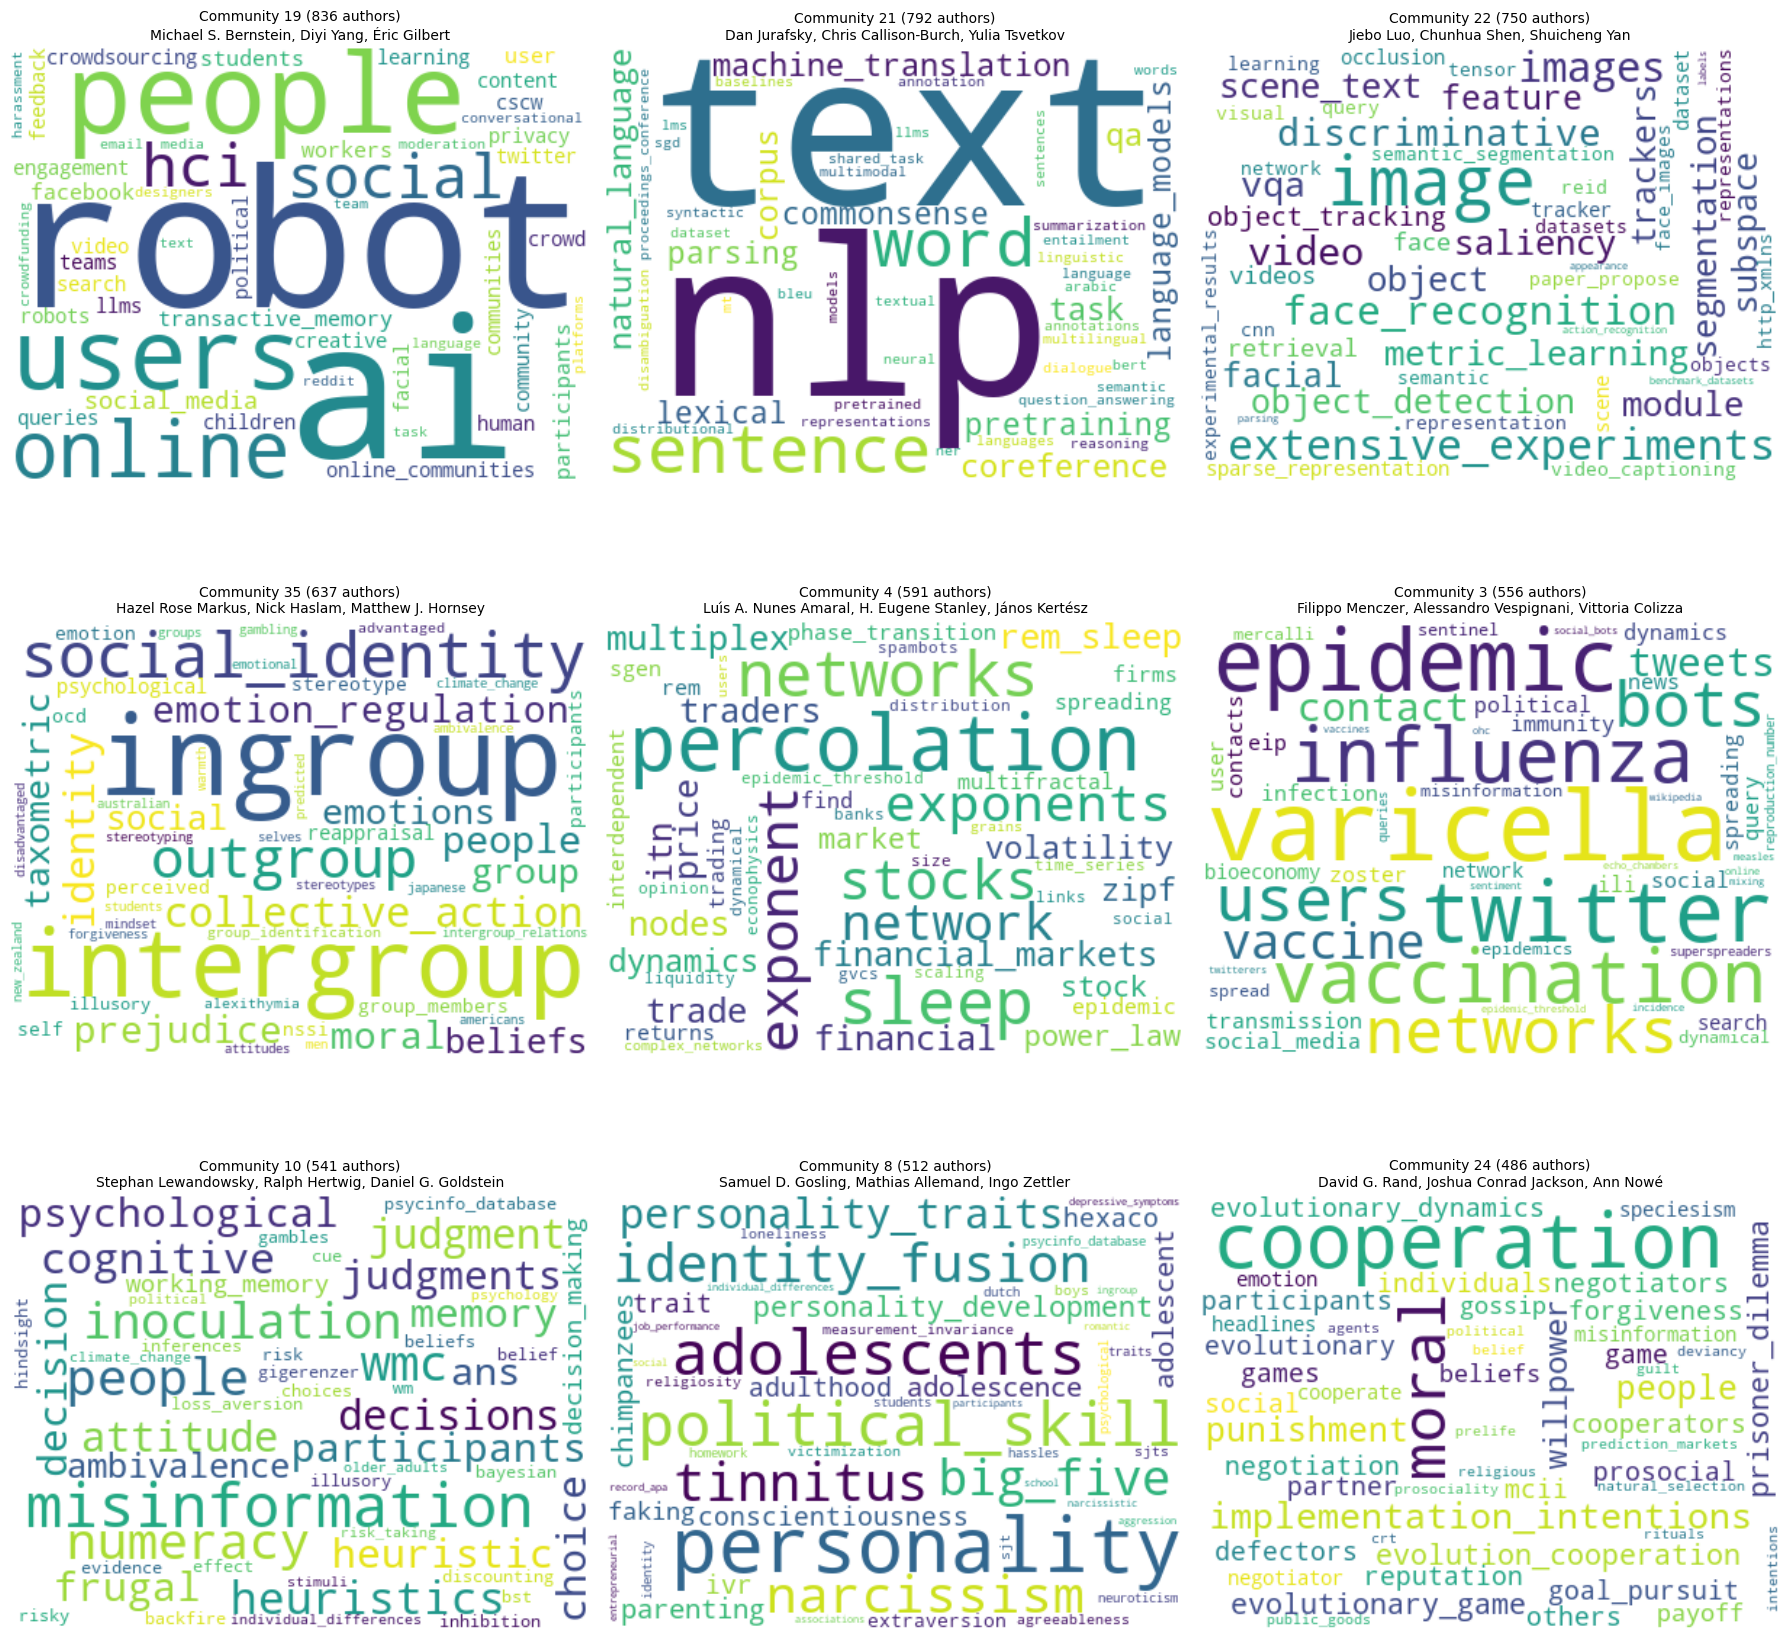

In [30]:
from wordcloud import WordCloud

fig, axes = plt.subplots(3, 3, figsize=(18, 18))
author_names = dict(zip(authors["id"], authors["display_name"]))

for idx, c in enumerate(top9):
    ax = axes[idx // 3][idx % 3]
    
    # use TF-IDF scores as word weights
    wc = WordCloud(width=400, height=300, background_color="white", max_words=50)
    wc.generate_from_frequencies(comm_tfidf[c])
    ax.imshow(wc, interpolation="bilinear")
    
    # top 3 authors
    comm_authors = [aid for aid, comm in comm_dict.items() if comm == c]
    top_authors = sorted(comm_authors, key=lambda a: degrees.get(a, 0), reverse=True)[:3]
    names = [author_names.get(a, "?") for a in top_authors]
    
    ax.set_title(f"Community {c} ({comm_sizes[c]} authors)\n{', '.join(names)}", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.savefig("week8_wordclouds.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

**Exercise 2 — Community descriptions:**
the wordclouds reveal distinct research subfields within CSS:
- community 19: HCI and AI — robots, users, online communities, social media
- community 21: NLP — text, sentence, machine translation, coreference
- community 22: computer vision — image, face recognition, object detection
- community 35: social psychology — ingroup/outgroup, social identity, prejudice
- community 4: complex systems / econophysics — percolation, financial markets, power law
- community 3: computational epidemiology + social media — vaccination, influenza, twitter
- community 10: cognitive science / misinformation — heuristics, judgment, inoculation
- community 8: personality psychology — big five, narcissism, personality traits
- community 24: cooperation and moral psychology — evolutionary game, prisoner dilemma, punishment

looking up the top authors confirms these findings: dan jurafsky is a leading 
NLP researcher, jiebo luo works in computer vision, filippo menczer studies 
misinformation and social media, samuel gosling is known for personality 
psychology research. the communities make sense.

 __Exercise 3: Computational Social Science__ 

> * In light of your data-driven analysis, has your understanding of the field changed? How? 

yes — CSS is much broader than expected. it's not just "social science with 
computers." it spans from hard physics (econophysics, percolation theory) to 
psychology (personality, intergroup relations) to AI/NLP to epidemiology. what 
ties them together is the use of computational methods and large-scale data to 
study human behavior, but the research questions and methods vary enormously 
across communities. the field is really a meeting point for many disciplines 
rather than a single coherent field.